In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===================== 全局设置 Times New Roman 字体 =====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# ---------------------- 读取你的 CSV ----------------------
df = pd.read_csv("March_all_cleaned_simplified.csv")

# ---------------------- 定义列 ----------------------
pollutants = ["CO", "NO2", "PM25", "PM10", "O3"]
city_features = df.columns[5:].tolist()

# ---------------------- 计算 5×30 Spearman 相关矩阵 ----------------------
corr_matrix = pd.DataFrame(index=pollutants, columns=city_features)

for p in pollutants:
    for c in city_features:
        corr_matrix.loc[p, c] = df[p].corr(df[c], method="pearson")

corr_matrix = corr_matrix.astype(float)

# ---------------------- 画图 ----------------------
plt.figure(figsize=(22, 7))

sns.heatmap(
    corr_matrix,
    cmap="seismic",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    annot_kws={"size": 16, "fontfamily": "Times New Roman", 'fontweight': 'bold'},  # 数字也强制 Times
    vmin=-1, vmax=1
)

# 坐标轴标签（强制 Times New Roman）
plt.xticks(rotation=45, ha='right', fontsize=20, fontfamily="Times New Roman")
plt.yticks(rotation=0, fontsize=20, fontfamily="Times New Roman")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'March_all_cleaned_simplified.csv'

C:\Users\william\AppData\Local\Temp\ipykernel_25668\62728631.py:10: DtypeWarning: Columns (35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("10月份之后的_街道语义分类作图和空气质量和物体识别.csv")


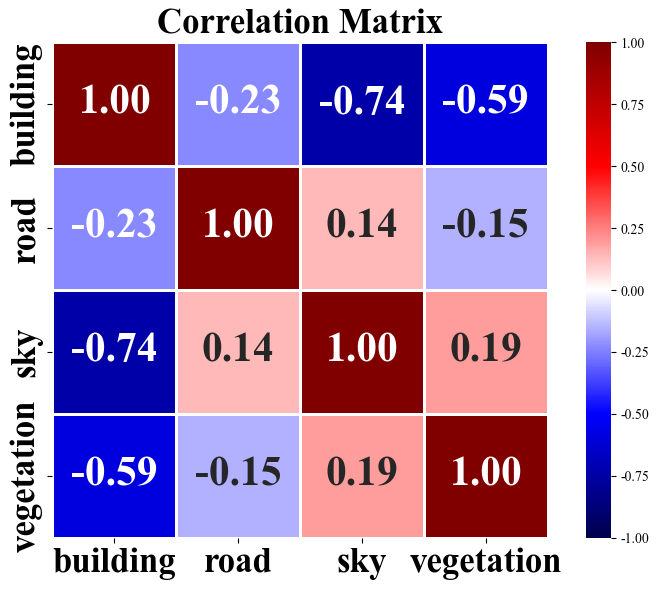

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===================== 全局设置 Times New Roman 字体 =====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------- 读取你的 CSV ----------------------
df = pd.read_csv("10月份之后的_街道语义分类作图和空气质量和物体识别.csv")

# ---------------------- 只保留 4 个特征 ----------------------
features = ["building", "road", "sky", "vegetation"]

# ---------------------- 计算 4×4 Pearson 相关矩阵 ----------------------
corr_matrix = df[features].corr(method="spearman")

# ---------------------- 画图：4×4 紧凑高清热力图 ----------------------
plt.figure(figsize=(8, 6))  # 紧凑正方形

sns.heatmap(
    corr_matrix,
    cmap="seismic",       # 红蓝配色，论文最常用
    center=0,             # 0为中心
    annot=True,           # 显示相关系数数字
    fmt=".2f",            # 保留2位小数
    linewidths=1,         # 格子分隔线
    linecolor="white",    # 分隔线白色更干净
    annot_kws={"size": 30, "fontweight": "bold"},  # 系数字体大小
    vmin=-1, vmax=1,      # 相关系数范围
    square=True           # 正方形格子
)

# 坐标轴字体
plt.xticks(fontsize=25, fontweight="bold")
plt.yticks(fontsize=25, fontweight="bold")

# 标题（可选）
plt.title("Correlation Matrix", fontsize=25, fontweight="bold")

plt.tight_layout()
plt.show()